# Aula 4 - Laboratório: Construindo um MLP do Zero com NumPy (Questão 1 da lista)

**Objetivo:** Implementar a mecânica do forward e backward pass para treinar um MLP em um problema não-linear, construindo um mini-framework modular com classes para camadas, custos, regularizadores e otimizadores.

---


## Parte 0: Configuração Inicial

Começamos importando as bibliotecas que usaremos hoje: NumPy para os cálculos, Matplotlib para visualização e Scikit-learn para gerar nossos datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.datasets import make_moons, make_circles, make_blobs
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

import torch
import torch.nn as nn
import torch.optim as optim 

# Configurações de estilo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14})

## Parte 1: Fundamentos Teóricos (Revisão)

Antes de mergulhar no código, vamos recapitular a teoria que fundamenta nosso laboratório.

### O MLP como um Aproximador de Funções

Uma Feedforward Neural Network (FNN), ou Multilayer Perceptron (MLP), é uma função parametrizada $h(\mathbf{x}; \theta)$ que aprende um mapeamento de uma entrada $\mathbf{x}$ para uma saída $\hat{\mathbf{y}}$. Os parâmetros $\theta$ são os pesos $\mathbf{W}$ e vieses $\mathbf{b}$ de cada camada.

### O Ciclo de Treinamento
O treinamento ocorre em um ciclo iterativo:
1.  **Forward Pass:** Calculamos a predição da rede, $\hat{\mathbf{y}} = h(\mathbf{x}; \theta)$.
2.  **Cálculo do Custo:** Medimos o erro da predição usando uma função de custo, $J = L(\hat{\mathbf{y}}, \mathbf{y})$.
3.  **Backward Pass:** Usamos o algoritmo de Backpropagation para calcular o gradiente do custo em relação a cada parâmetro, $\nabla_{\theta} J$.
4.  **Atualização dos Pesos:** Ajustamos os parâmetros na direção oposta ao gradiente, $\theta \leftarrow \theta - \eta \nabla_{\theta} J$.

### O Backward Pass em Detalhe

O Backpropagation é a aplicação da regra da cadeia. A variável central é o "sinal de erro" $\boldsymbol{\delta}^{(l)} = \frac{\partial J}{\partial \mathbf{z}^{(l)}}$, que é o gradiente do custo em relação à entrada linear da camada $l$. Propagamos este sinal para trás:

-   **Erro na camada $l$ (a partir da $l+1$):** $\boldsymbol{\delta}^{(l)} = ( (\mathbf{W}^{(l+1)})^T \boldsymbol{\delta}^{(l+1)} ) \odot \sigma_l'(\mathbf{z}^{(l)})$
-   **Gradiente dos Pesos:** $\frac{\partial J}{\partial \mathbf{W}^{(l)}} = \boldsymbol{\delta}^{(l)} (\mathbf{a}^{(l-1)})^T$
-   **Gradiente do Viés:** $\frac{\partial J}{\partial \mathbf{b}^{(l)}} = \boldsymbol{\delta}^{(l)}$

### Otimizador SGD e Regularização|

A otimização e a regularização são dois dos conceitos mais importantes no treinamento de redes neurais. Eles controlam *como* o modelo aprende e *quão bem* ele generaliza para novos dados.

---
#### Descida de Gradiente Estocástica (SGD)

A **Descida de Gradiente Estocástica (SGD)** é o algoritmo de otimização que impulsiona a maioria dos modelos de aprendizado profundo. É uma variação eficiente da Descida de Gradiente tradicional (Batch).

* **Batch Gradient Descent:** Calcula o gradiente da função de custo usando o **dataset de treinamento inteiro** a cada passo. Isso resulta em uma estimativa precisa da direção ideal para o mínimo, mas é computacionalmente inviável para os grandes datasets usados hoje.
* **Stochastic Gradient Descent:** Em vez de usar todos os dados, o SGD aproxima o gradiente usando **um único exemplo** de treinamento por vez. Isso torna cada atualização de peso extremamente rápida. A versão mais comum na prática é o **Mini-Batch SGD**, que calcula o gradiente sobre um pequeno lote (mini-batch) de dados (e.g., 32 a 256 exemplos).

A regra de atualização para o Mini-Batch SGD é:
$$\theta^{(t+1)} \leftarrow \theta^{(t)} - \eta \left( \frac{1}{B} \sum_{n \in \mathcal{B}} \nabla_{\theta} L(h(\mathbf{x}_n; \theta), y_n) \right)$$
Onde $\mathcal{B}$ é o mini-batch de tamanho $B$. O gradiente calculado é uma estimativa "ruidosa" do gradiente real, mas essa aleatoriedade muitas vezes ajuda o modelo a escapar de mínimos locais rasos e a convergir mais rapidamente.

---
#### Regularização

A **regularização** é um conjunto de técnicas usadas para combater o **overfitting**. Overfitting ocorre quando um modelo se ajusta tão bem aos dados de treino (incluindo seu ruído) que perde a capacidade de generalizar para dados não vistos. A regularização alcança isso adicionando um termo de penalidade $\Omega(\theta)$ à função de custo, que desencoraja a complexidade do modelo.

O objetivo de otimização se torna:
$$J(\theta) = \hat{R}(h_\theta) + \lambda \Omega(\theta)$$

### Principais Tipos de Regularização

* **Regularização L2 (Weight Decay):**
    * **Penalidade:** $\Omega(\theta) = \frac{1}{2} \sum_i w_i^2 = \frac{1}{2} ||\mathbf{w}||_2^2$. Adiciona a soma dos quadrados dos pesos ao custo.
    * **Efeito:** Penaliza pesos grandes, incentivando o modelo a encontrar soluções com pesos menores e mais distribuídos. Isso resulta em uma função mais "suave" e menos propensa a se ajustar ao ruído. No passo de atualização do SGD, isso é equivalente a "decaimento de peso" (*weight decay*), onde os pesos são ligeiramente reduzidos a cada passo.

* **Regularização L1 (Lasso):**
    * **Penalidade:** $\Omega(\theta) = \sum_i |w_i| = ||\mathbf{w}||_1$. Adiciona a soma dos valores absolutos dos pesos.
    * **Efeito:** A regularização L1 tem a propriedade de poder levar alguns pesos a serem **exatamente zero**. Isso efetivamente remove conexões da rede, realizando uma forma de seleção de features automática e resultando em um modelo **esparso**.


## Parte 2: A Arquitetura do Nosso Código

Vamos encapsular cada componente em sua própria classe para criar um código modular e flexível.

In [2]:
class Differentiable:
    """Classe base para todas as funcionalidades diferenciáveis."""
    def forward(self, input_data):
        raise NotImplementedError
    def backward(self, output_grad):
        raise NotImplementedError

class Layer(Differentiable):
    """Classe base para todas as camadas da rede neural com paraâmetros."""
    def forward(self, input_data):
        raise NotImplementedError
    def backward(self, output_grad):
        raise NotImplementedError
    def params(self):
        """Retorna os parâmetros e gradientes da camada."""
        return [], []



## Parte 3: Implementação Passo a Passo

Agora, vamos preencher o esqueleto do nosso mini-framework.

In [3]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)


### 3.1 Camada Linear

In [4]:
class Linear(Layer):
    def __init__(self, input_size, output_size):
        self.W = np.random.randn(input_size, output_size) * 0.1
        self.b = np.zeros((1, output_size))
        self.input_data = None
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.input_size = input_size
        self.output_size = output_size

    def forward(self, input_data):
        self.input_data = input_data
        return np.dot(input_data, self.W) + self.b

    def backward(self, output_grad):
        # gradientes
        self.dW = np.dot(self.input_data.T, output_grad)
        self.db = np.sum(output_grad, axis=0, keepdims=True)
        # gradiente para trás
        dx = np.dot(output_grad, self.W.T)
        return dx

    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]


### 3.2 Camada de Ativação (Sigmóide)

In [5]:
class Sigmoid(Differentiable):
    def __init__(self):
        self.output = None

    def forward(self, input_data):
        # Armazene o resultado em self.output para usar no backward pass.
        self.output = sigmoide(input_data)
        return self.output

    def backward(self, output_grad):
        # sigma'(z) = sigma(z) * (1 - sigma(z))
        return output_grad * (self.output * (1 - self.output))

class ReLU(Differentiable):
    def __init__(self):
        self.output = None

    def forward(self, input_data):
        # Armazene o resultado em self.output para usar no backward pass.
        self.output = relu(input_data)
        return self.output

    def backward(self, output_grad):
        
        # A derivada é output_grad * relu'(z).
        #return output_grad * self.output
        return output_grad * (self.output > 0).astype(float)

### 3.3 Função de Custo (MSE)

In [6]:
class MSELoss(Differentiable):
    def forward(self, y_pred, y_true):
        # TODO: Implementar o cálculo do Erro Quadrático Médio (MSE).
        self.y_pred = y_pred
        self.y_true = y_true
        return np.mean((y_pred - y_true)**2)

    def backward(self):
        n = len(self.y_true)
        return 2 * (self.y_pred - self.y_true) / n

class BinaryCrossEntropyLoss(Differentiable):
    def forward(self, y_pred, y_true):
        # evitar log(0)
        self.y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        self.y_true = y_true
        return -np.mean(
            y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred)
        )
    
    def backward(self):
        n = self.y_true.shape[0]  
        return (self.y_pred - self.y_true) / (n * self.y_pred * (1 - self.y_pred))


### 3.4 Modelo Sequencial

In [7]:
class Sequential(Layer):
    def __init__(self, layers):
        self.layers = layers

    def forward(self, input_data):
        for layer in self.layers:
            input_data = layer.forward(input_data)
        return input_data

    def backward(self, output_grad):
        for layer in reversed(self.layers):
            output_grad = layer.backward(output_grad)
            
    def params(self):
        parameters = []
        for layer in self.layers:
            if hasattr(layer,"params"):
                parameters.extend(layer.params())
        return parameters

### 3.5 O Otimizador (SGD)

In [ ]:
class SGD:
    def __init__(self, model, learning_rate):
        self.model = model
        self.learning_rate = learning_rate
    def step(self):
        for param, grad in self.model.params():
            param -= self.learning_rate * grad  
            
    def zero_grad(self):
        for _, grad in self.model.params():
            grad[...] = 0  

#### 3.5.1 Regularização (L2)



In [9]:
class L2Regularization(Differentiable):
    def __init__(self, model, lambda_, eta):
        self.model = model
        self.lambda_ = lambda_
        self.eta = eta

    def forward(self, input_data):
        # TODO: Implementar o forward pass da regularização L2.
        # forward(model): Itera sobre as camadas do modelo, calcula e retorna a penalidade L2 total.
        # a penalidade eh dada pela formula jreg = lambda/2 * sum(||w||2f)
        reg = 0
        for layer in self.model.layers:
            params = layer.params()
            if len(params) == 0:
                continue
            w = params[0][0]
            reg += np.sum(w**2)
        reg = self.lambda_/2 * reg
        return reg
    
    def backward(self, output_grad):
        # TODO: Implementar o backward pass da regularização L2.
        # colocar a regularização no dw
        for layer in self.model.layers:
            params = layer.params()
            if len(params) == 0:
                continue
            w = params[0][0]
            layer.dw = self.lambda_ * w

    def step(self):
        # TODO: Implementar o passo de atualização dos pesos com regularização L2.
        for index, param in enumerate(self.model.params()):
            if len(param) == 0:
                continue
            if (index %2 == 0):
                # fazer w <- w - (lr * (dw + lambda * W))
                self.model.layers[index].w = param[0] - self.eta * (param[1] + self.lambda_ * param[0])
            else:
                self.model.layers[index].b = param[0] - self.eta * param[1]

### 3.6 Treinando o Modelo

Agora, vamos usar nossas classes para treinar um MLP no dataset `make_moons`.

#### 3.6.1 - Carregar e visualizar os dados

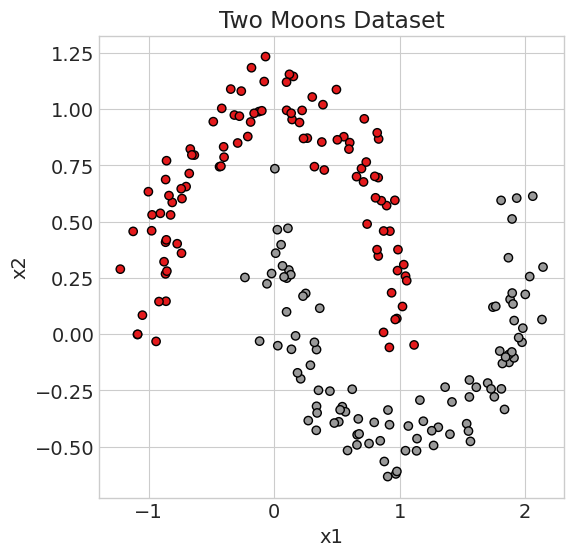

In [10]:
# gerar os dados
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
y_moons = y_moons.reshape(-1, 1) 

# plot
plt.figure(figsize=(6, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons.ravel(), cmap=plt.cm.Set1, edgecolor="k")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Moons Dataset")
plt.show()


In [11]:
# Definir a arquitetura do modelo
model_moons = Sequential([
    Linear(2, 16),
    Sigmoid(),
    Linear(16, 1),
    Sigmoid()
])

# Instanciar os componentes
loss_fn = BinaryCrossEntropyLoss()
optimizer_moons = SGD(model_moons, learning_rate=0.15)

epochs = 5000
loss_history_moons = []

# Loop de Treinamento
for epoch in range(epochs):
    # TODO: Preencha o loop de treinamento usando os métodos das suas classes.
    # 1. Forward pass
    y_pred = model_moons.forward(X_moons) # Substitua
    
    # 2. Calcular o custo
    loss = loss_fn.forward(y_pred=y_pred, y_true=y_moons) # Substitua
    loss_history_moons.append(loss)
    
    # 3. Zerar gradientes anteriores
    optimizer_moons.zero_grad()
    # Chame o método do otimizador
    
    # 4. Backward pass
    grad_initial = loss_fn.backward() # Obtenha o gradiente inicial da função de custo
    # Chame o backward do modelo
    model_moons.backward(grad_initial)
    
    # 5. Atualizar os pesos
    # Chame o método do otimizador
    optimizer_moons.step()
    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')

Epoch [500/5000], Loss: 0.3131
Epoch [1000/5000], Loss: 0.2779
Epoch [1500/5000], Loss: 0.2756
Epoch [2000/5000], Loss: 0.2753
Epoch [2500/5000], Loss: 0.2751
Epoch [3000/5000], Loss: 0.2750
Epoch [3500/5000], Loss: 0.2748
Epoch [4000/5000], Loss: 0.2747
Epoch [4500/5000], Loss: 0.2746
Epoch [5000/5000], Loss: 0.2745


In [ ]:
def train_model(model, loss_fn, optimizer, X, y, epochs=5000, interval= 500):
    loss_history = []
    for epoch in range(epochs):
        y_pred = model.forward(X)

        loss = loss_fn.forward(y_pred, y)
        loss_history.append(loss)

        optimizer.zero_grad()

        grad_initial = loss_fn.backward()

        model.backward(grad_initial)
        optimizer.step()

        if (epoch+1) % interval == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')
    return model, loss_history

# Definir a arquitetura do modelo
model_moons = Sequential([
    Linear(2, 16),
    Sigmoid(),
    Linear(16, 1),
    Sigmoid()
])
# Instanciar os componentes
optimizer_moons = SGD(model_moons, learning_rate=0.15)
loss_fn = BinaryCrossEntropyLoss()

model_moons, loss_history_moons = train_model(model= model_moons, loss_fn= loss_fn, optimizer=optimizer_moons, X =X_moons, y=y_moons)


Epoch [500/5000], Loss: 0.3096
Epoch [1000/5000], Loss: 0.2772
Epoch [1500/5000], Loss: 0.2751
Epoch [2000/5000], Loss: 0.2749
Epoch [2500/5000], Loss: 0.2747
Epoch [3000/5000], Loss: 0.2746
Epoch [3500/5000], Loss: 0.2745
Epoch [4000/5000], Loss: 0.2745
Epoch [4500/5000], Loss: 0.2744
Epoch [5000/5000], Loss: 0.2743


### 3.7 Visualização da Fronteira

Vamos plotar a fronteira de decisão para ver o que nosso modelo aprendeu.

In [13]:
def plot_loss(loss_history, name = ""):
    plt.figure(figsize=(8,6))
    plt.plot(loss_history)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Curva de Perda {name}")
    plt.show()    

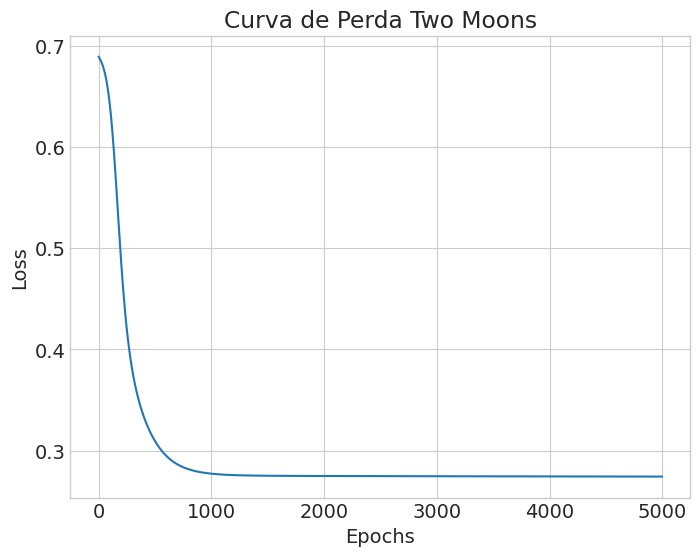

In [14]:
plot_loss(loss_history_moons, "Two Moons")

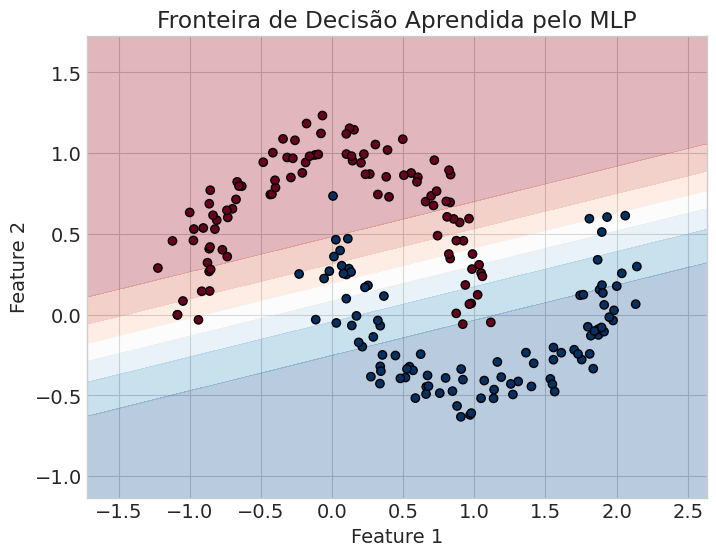

In [15]:
def plot_decision_boundary(model, X, y, step=0.01):
    # Definir limites do grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    
    # Previsões no grid
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.forward(grid)
    preds = preds.reshape(xx.shape)
    
    # Desenhar regiões
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors="k")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Fronteira de Decisão Aprendida pelo MLP")
    plt.show()

# Exemplo de uso depois do treino
plot_decision_boundary(model_moons, X_moons, y_moons)

## Exercício 4: Inspecionando a Rede

Tão importante quanto construir um modelo é ser capaz de inspecioná-lo. Isso nos ajuda a depurar, entender a complexidade e garantir que a arquitetura que montamos é realmente a que pretendíamos.

**4.1. Visualizando a Estrutura em Texto**

Uma representação em texto é a forma mais simples e direta de verificar a estrutura de um modelo. Em frameworks como PyTorch, quando você imprime um objeto de modelo, um método especial (`__repr__`) é chamado para gerar uma descrição legível.

**Tarefa:** Adicione o método `__repr__` à sua classe `Sequential`. Ele deve iterar sobre as camadas e construir uma string que lista cada camada com seu índice e uma breve descrição (e.g., `Linear(in=2, out=16)`).


In [16]:
def __repr__(self):
    layers = self.layers
    self.description = []
    last_out = None
    for layer in layers:
        if hasattr(layer, "input_size"):
            print(f"{type(layer).__name__}(in={layer.input_size}, out={layer.output_size})")
            self.description.append(f"{type(layer).__name__}(in = {layer.input_size}), out = {layer.output_size}")
            last_out = layer.output_size
        else:
            print(f"{type(layer).__name__}(in={last_out}, out={last_out})")
__repr__(model_moons)

Linear(in=2, out=16)
Sigmoid(in=16, out=16)
Linear(in=16, out=1)
Sigmoid(in=1, out=1)


In [17]:
Sequential.__repr__ = __repr__

In [18]:
model_moons.__repr__()

Linear(in=2, out=16)
Sigmoid(in=16, out=16)
Linear(in=16, out=1)
Sigmoid(in=1, out=1)



**4.2. Visualizando a Estrutura Graficamente**

Uma visualização gráfica pode oferecer uma intuição ainda melhor sobre o fluxo de dados.

**Tarefa:** Crie uma função que receba seu modelo `Sequential` e use o `matplotlib` para desenhar um diagrama da arquitetura. Uma sugestão é representar cada camada como um bloco retangular, mostrando o tipo de camada e a forma dos dados que fluem entre elas.


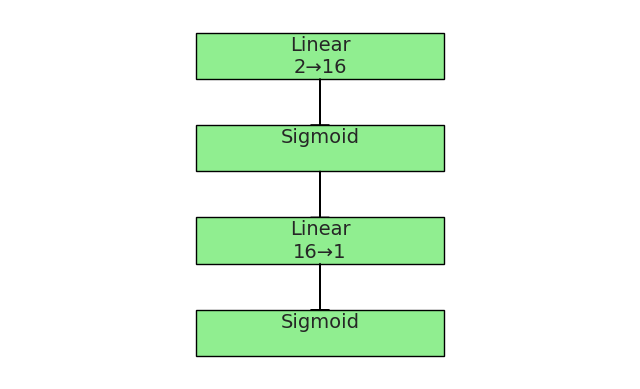

In [19]:
def visNet(model):
    fig, ax = plt.subplots(figsize=(8, len(model.layers) * 1.2))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(model.layers) * 2)
    ax.axis("off")

    y = len(model.layers) * 2 - 1
    prev_shape = None

    for i, layer in enumerate(model.layers):
        layer_name = type(layer).__name__
        # Pega parâmetros se existirem
        if hasattr(layer, "W"):
            shape = f"{layer.W.shape[0]}→{layer.W.shape[1]}"
        else:
            shape = ""
        rect = patches.Rectangle((3, y - 0.5), 4, 1, linewidth=1,
                                 edgecolor='black', facecolor='lightgreen')
        ax.add_patch(rect)
        ax.text(5, y, f"{layer_name}\n{shape}", ha="center", va="center")
        if i < len(model.layers) - 1:
            ax.arrow(5, y - 0.5, 0, -1, head_width=0.3, head_length=0.3, fc='k', ec='k')
        y -= 2
    plt.show()

visNet(model_moons)



**4.3. Visualizando a Função de Ativação**

É uma boa prática de sanidade verificar se nossas implementações matemáticas estão corretas.

**Tarefa:**  Crie uma função simples que receba um objeto de camada de ativação (e.g., Sigmoid()) e plote sua saída e sua derivada para um intervalo de entradas (e.g., de -5 a 5). Verifique se os gráficos correspondem às formas teóricas.

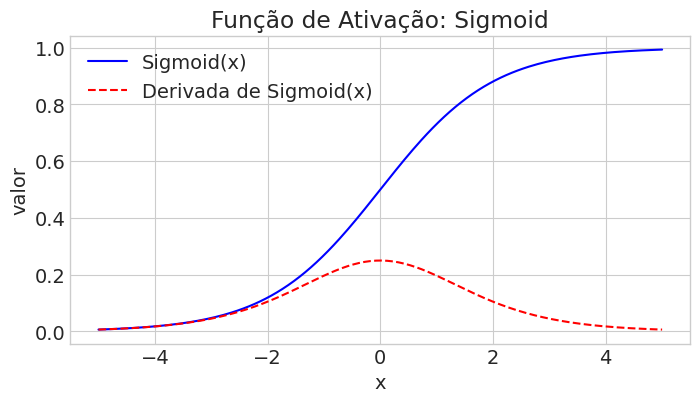

In [20]:
def plot_activation_function(layer, x_range=(-5, 5), num_points=200):
    x = np.linspace(x_range[0], x_range[1], num_points)
    y = layer.forward(x)

    if isinstance(layer, Sigmoid):
        dy = y * (1 - y)
    elif isinstance(layer, ReLU):
        dy = (x > 0).astype(float)
        
    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label=f"{type(layer).__name__}(x)", color="blue")
    if dy is not None:
        plt.plot(x, dy, label=f"Derivada de {type(layer).__name__}(x)", color="red", linestyle="--")

    plt.title(f"Função de Ativação: {type(layer).__name__}")
    plt.xlabel("x")
    plt.ylabel("valor")
    plt.legend()
    plt.grid(True)
    plt.show()
    
sigmoid = Sigmoid()
plot_activation_function(sigmoid)


## Exercício 5: Testando outros datasets e variações na arquitetura

Um bom modelo deve ser flexível. Vamos agora testar nosso framework em outros problemas de classificação clássicos para ver como ele se comporta e a importância de ajustar a arquitetura.

**A Tarefa:**

Modifique sua rede e os hiperparâmetros de treinamento (taxa de aprendizado, número de épocas, número de neurônios/camadas) para resolver os seguintes problemas:

1.  **Círculos Concêntricos:** Use `make_circles` do scikit-learn.
2.  **XOR:** Crie os 4 pontos de dados do problema XOR manualmente.
3.  **MNIST (dois dígitos):** Carregue o dataset MNIST, filtre para manter apenas dois dígitos (e.g., 3 e 8), e treine um classificador binário.

Para cada dataset, o objetivo é gerar uma visualização da fronteira de decisão que separe as classes corretamente. Observe como diferentes arquiteturas podem ser necessárias para cada problema.

### **5.1 círculos concêntricos**

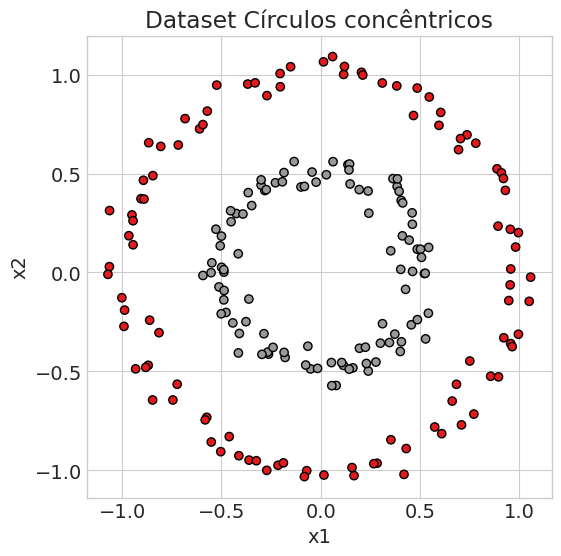

In [21]:
# Circles
X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
y_circles = y_circles.reshape(-1, 1) 

plt.figure(figsize=(6, 6))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles.ravel(), cmap=plt.cm.Set1, edgecolor="k")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset Círculos concêntricos")
plt.show()

In [31]:
# Definir a arquitetura do modelo
model_circles = Sequential([
    Linear(2, 16),
    ReLU(),
    Linear(16, 1),
    Sigmoid()
])

# Instanciar os componentes
loss_fn = BinaryCrossEntropyLoss()
optimizer_circles = SGD(model_circles, learning_rate=0.15)

model_circles, loss_history_circles = train_model(model_circles, loss_fn, optimizer_circles, X_circles, y_circles)

Epoch [500/5000], Loss: 0.3746
Epoch [1000/5000], Loss: 0.0776
Epoch [1500/5000], Loss: 0.0313
Epoch [2000/5000], Loss: 0.0183
Epoch [2500/5000], Loss: 0.0125
Epoch [3000/5000], Loss: 0.0094
Epoch [3500/5000], Loss: 0.0075
Epoch [4000/5000], Loss: 0.0062
Epoch [4500/5000], Loss: 0.0052
Epoch [5000/5000], Loss: 0.0045


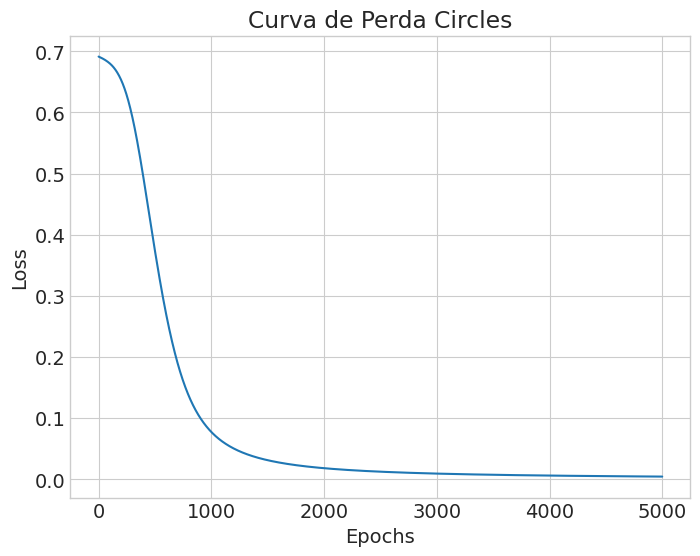

In [32]:
plot_loss(loss_history_circles, "Circles")

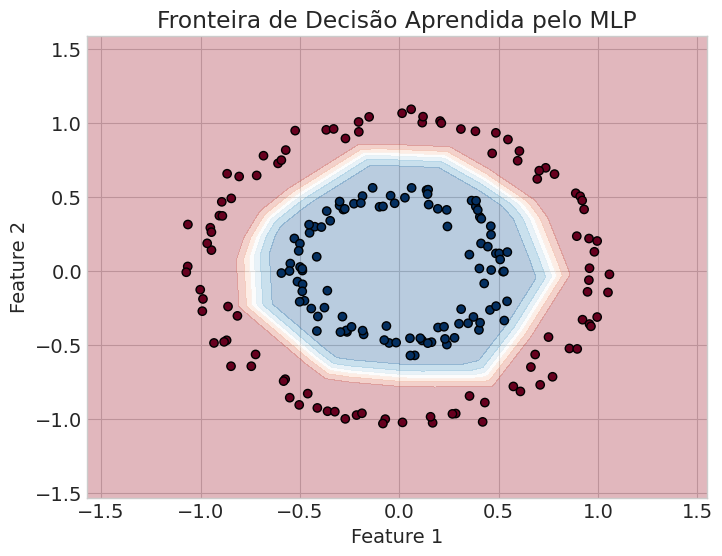

In [33]:
plot_decision_boundary(model_circles, X=X_circles, y=y_circles)

### **5.2 XOR**

In [26]:
# XOR
X_xor, y_moons = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=2.0, random_state=42)
y_xor=y_moons%2
y_xor = y_xor.reshape(-1, 1) 


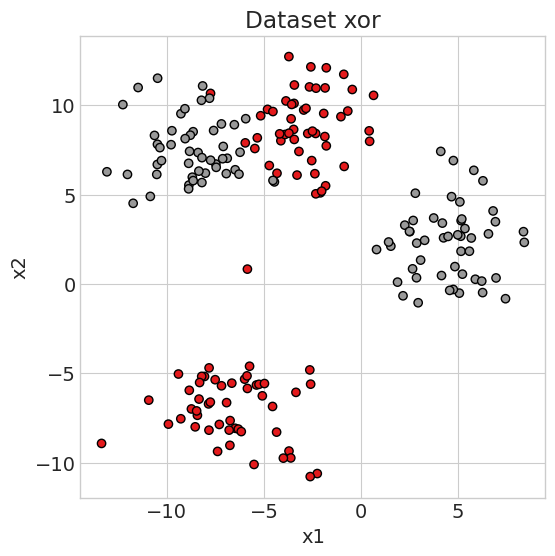

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.ravel(), cmap=plt.cm.Set1, edgecolor="k")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset xor")
plt.show()

In [30]:
# Definir a arquitetura do modelo
model_xor = Sequential([
    Linear(2, 16),
    ReLU(),
    Linear(16, 1),
    Sigmoid()
])

# Instanciar os componentes
loss_fn = BinaryCrossEntropyLoss()
optimizer_xor = SGD(model_xor, learning_rate=0.15)

model_xor, loss_history_xor = train_model(model_xor, loss_fn, optimizer_xor, X_xor, y_xor)

Epoch [500/5000], Loss: 0.0487
Epoch [1000/5000], Loss: 0.0445
Epoch [1500/5000], Loss: 0.0431
Epoch [2000/5000], Loss: 0.0424
Epoch [2500/5000], Loss: 0.0420
Epoch [3000/5000], Loss: 0.0418
Epoch [3500/5000], Loss: 0.0416
Epoch [4000/5000], Loss: 0.0415
Epoch [4500/5000], Loss: 0.0415
Epoch [5000/5000], Loss: 0.0414


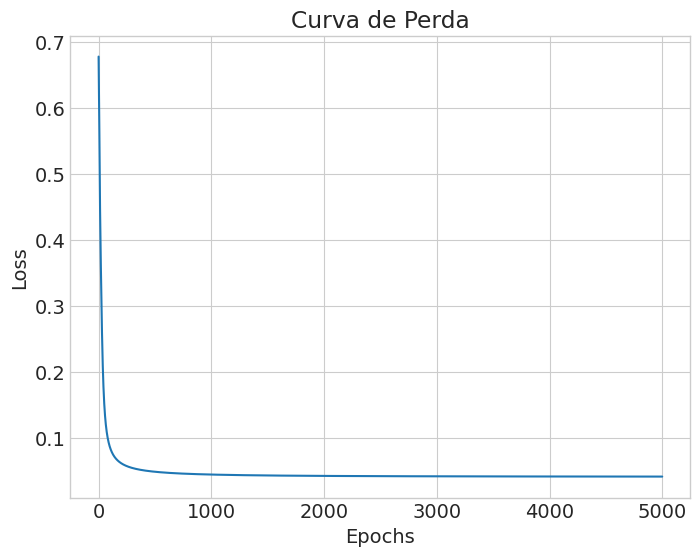

In [34]:
plt.figure(figsize=(8,6))
plt.plot(loss_history_xor)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Curva de Perda")
plt.show()

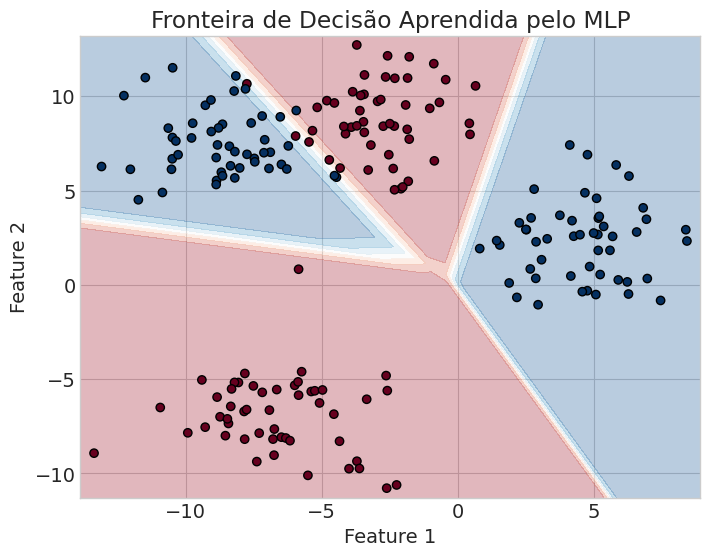

In [28]:
plot_decision_boundary(model_xor, X_xor, y_xor)

### **5.3 MNIST binário**

In [35]:

# Carregar o dataset MNIST
train_data = MNIST(root='./data', train=True, download=True, transform=ToTensor())

# Filtrar para manter apenas os dígitos 0 e 1
mask = (train_data.targets == 0) | (train_data.targets == 1)
data = train_data.data[mask].float() / 255.0  # Normalizar para [0, 1]
labels = train_data.targets[mask]

# Flatten das imagens (28x28 -> 784) e converter p/ NumPy
data_flat = data.reshape(-1, 28 * 28).numpy()
labels = labels.numpy().astype(np.float32).reshape(-1, 1)


# Função para normalizar e remodelar para exibição
def prep_for_display(pc_vector, img_size=(28, 28)):
    img = pc_vector.reshape(img_size[0], img_size[1])
    # Normalizar para o intervalo [0, 1] para visualização
    img = (img - img.min()) / (img.max() - img.min())
    return img

# Função pra mostrar uma imagem da saida ou layers da rede neural
def show_image(pc_vector):
    img = prep_for_display(pc_vector)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

In [17]:
# Definir a arquitetura do modelo
model_mnist = Sequential([
    Linear(784, 16),
    ReLU(),
    Linear(16, 1),
    Sigmoid()
])

# Instanciar os componentes
loss_fn = BinaryCrossEntropyLoss()
optimizer_mnist = SGD(model_mnist, learning_rate=0.15)

epochs = 1000
loss_history_mnist = []

# Loop de Treinamento
for epoch in range(epochs):
    # TODO: Preencha o loop de treinamento usando os métodos das suas classes.
    # 1. Forward pass
    y_pred = model_mnist.forward(data_flat) # Substitua
    
    # 2. Calcular o custo
    loss = loss_fn.forward(y_pred=y_pred, y_true=labels) # Substitua
    loss_history_mnist.append(loss)
    
    # 3. Zerar gradientes anteriores
    optimizer_mnist.zero_grad()
    # Chame o método do otimizador
    
    # 4. Backward pass
    grad_initial = loss_fn.backward() # Obtenha o gradiente inicial da função de custo
    # Chame o backward do modelo
    model_mnist.backward(grad_initial)
    
    # 5. Atualizar os pesos
    # Chame o método do otimizador
    optimizer_mnist.step()
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')

Epoch [500/1000], Loss: 0.0049
Epoch [1000/1000], Loss: 0.0034


In [38]:
# Definir a arquitetura do modelo
model_mnist = Sequential([
    Linear(784, 16),
    ReLU(),
    Linear(16, 1),
    Sigmoid()
])

# Instanciar os componentes
loss_fn = BinaryCrossEntropyLoss()
optimizer_mnist = SGD(model_mnist, learning_rate=0.15)

model_mnist, loss_history_mnist = train_model(model_mnist, loss_fn, optimizer_mnist, data_flat, labels, epochs= 1000, interval= 100)

Epoch [100/1000], Loss: 0.0119
Epoch [200/1000], Loss: 0.0079
Epoch [300/1000], Loss: 0.0064
Epoch [400/1000], Loss: 0.0055
Epoch [500/1000], Loss: 0.0049
Epoch [600/1000], Loss: 0.0045
Epoch [700/1000], Loss: 0.0041
Epoch [800/1000], Loss: 0.0038
Epoch [900/1000], Loss: 0.0036
Epoch [1000/1000], Loss: 0.0034


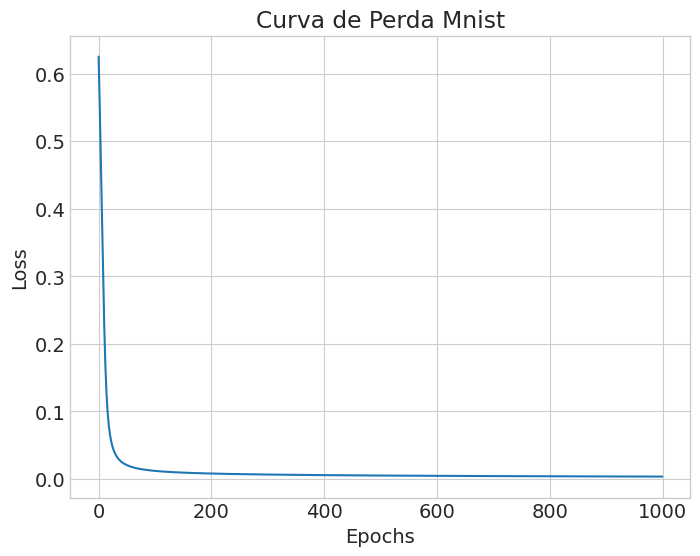

In [39]:
plot_loss(loss_history=loss_history_mnist, name="Mnist")

## Exercício 6: Adaptando a Rede para Regressão

Redes neurais não servem apenas para classificação. Com algumas modificações simples, podemos usá-las para aproximar funções contínuas e resolver problemas de regressão.

**A Tarefa:**

Modifique sua rede e o loop de treinamento para resolver um problema de regressão, ajustando uma curva a dados ruidosos.

**Mudanças Necessárias:**

1.  **Dados:** Gere dados a partir de uma função complexa com ruído Gaussiano. Por exemplo, $y = 6\sin(x)+8\cos(x)+x^2 + \text{ruído}$. Para um desafio extra, crie uma função que gera uma função-alvo aleatória a cada vez, escolhendo termos simples e coeficientes aleatórios.

2.  **Arquitetura:** A mudança mais importante é na camada de saída. Como a saída do modelo não é mais uma probabilidade no intervalo [0, 1], a ativação Sigmóide final deve ser **removida**. A saída da última camada `Linear` será diretamente a sua predição $\hat{y}$. As camadas internas podem continuar usando ativações como `ReLU` ou `Sigmoid`.

3.  **Custo:** A função de custo deve ser a `MSELoss` (Erro Quadrático Médio), que é a escolha padrão para regressão, pois corresponde à suposição de uma verossimilhança Gaussiana para o ruído dos dados.

In [16]:
class RandomRegressionData:
    def __init__(self):
        self.base_functions = {
        'sin': np.sin,
        'cos': np.cos,
        'square': np.square,
        'cube': lambda x: x**3,
        'linear': lambda x: x,
        'abs': np.abs,
        'sqrt_abs': lambda x: np.sqrt(np.abs(x)),
        'log_abs': lambda x: np.log(np.abs(x) + 1e-5)  # Evitar log(0)
        }

    def generate_random_regression_data(self, n_samples=200, noise=0.2, x_range=(-1, 4)):
        """
        Gera dados para um problema de regressão a partir de uma função-alvo
        aleatoriamente construída.

        A função-alvo é uma combinação linear de um subconjunto aleatório de
        funções de base, com coeficientes aleatórios.

        Args:
            n_samples (int): O número de pontos de dados a serem gerados.
            noise (float): A magnitude (desvio padrão) do ruído Gaussiano adicionado.
            x_range (tuple): O intervalo (min, max) para a variável de entrada x.

        Returns:
            tuple: Uma tupla contendo:
                - X (np.array): O vetor de entrada de formato (n_samples, 1).
                - y (np.array): O vetor de saída com ruído, de formato (n_samples, 1).
                - true_function_str (str): Uma string descrevendo a função real gerada.
        """
        # Gerar o domínio de entrada X
        X = np.linspace(x_range[0], x_range[1], n_samples).reshape(-1, 1)

        # Inicializar a saída y e a string da função
        y_true = np.zeros_like(X)
        true_function_str = "y = "

        # Escolher um número aleatório de termos para a função (entre 2 e 4)
        num_terms = np.random.randint(2, 5)
            
        # Selecionar um subconjunto aleatório de funções sem reposição
        chosen_funcs = np.random.choice(list(self.base_functions.keys()), num_terms, replace=False)

        terms = []
        for i, func_name in enumerate(chosen_funcs):
            # Gerar um coeficiente aleatório
            coeff = np.random.uniform(-1, 3)
                
            # Obter a função do dicionário
            func = self.base_functions[func_name]
                
            # Adicionar o termo à saída e à string
            y_true += coeff * func(X)
            terms.append((coeff, func_name))

            sign = "+" if coeff > 0 else "-"
            if i > 0:
                true_function_str += f" {sign} {abs(coeff):.2f} * {func_name}(x)"
            else:
                # Para o primeiro termo, não mostramos o sinal de +
                true_function_str += f"{coeff:.2f} * {func_name}(x)"

        # Adicionar ruído Gaussiano
        y_noisy = y_true + np.random.randn(n_samples, 1) * noise

        return X, y_noisy, true_function_str, terms

    def evaluate_function(self, X, terms):
        """
        Avalia a função real gerada em um conjunto de pontos X.

        Args:
            X (np.array): O vetor de entrada de formato (n_samples, 1).
            terms (list): A lista de termos (coeficiente, nome_da_função) que definem a função.

        Returns:
            np.array: O vetor de saída avaliado, de formato (n_samples, 1).
        """
        y_true = np.zeros_like(X)
        for coeff, func_name in terms:
            func = self.base_functions[func_name]
            y_true += coeff * func(X)
        return y_true


Função gerada: y = 1.83 * cube(x) + 0.76 * cos(x) + 0.97 * sqrt_abs(x)


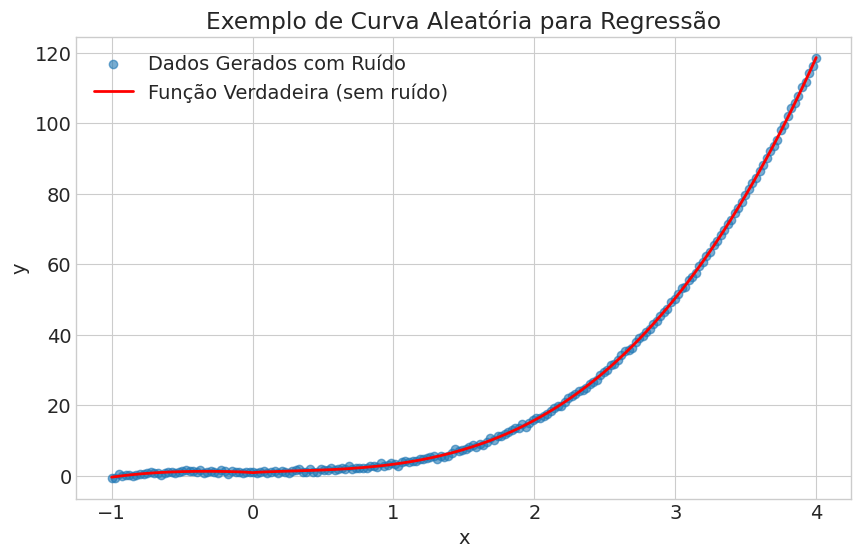

In [17]:
# Instanciar a classe
data_generator = RandomRegressionData()
# Gerar dados
X_data, y_data, func_str, func_terms = data_generator.generate_random_regression_data(n_samples=200, noise=0.3)

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_data, y_data, alpha=0.6, label='Dados Gerados com Ruído')

y_true = data_generator.evaluate_function(X_data, func_terms)
y_true = y_true.reshape(-1,1)
plt.plot(X_data, y_true, 'r-', lw=2, label='Função Verdadeira (sem ruído)')

plt.title("Exemplo de Curva Aleatória para Regressão")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
print("Função gerada:", func_str)
plt.show()


Treinamento do modelo

In [62]:
# Definir a arquitetura do modelo
model_regression = Sequential([
    Linear(1, 16),
    Sigmoid(),
    Linear(16, 1),
])

# Instanciar os componentes
loss_fn = MSELoss()
optimizer_regression = SGD(model_regression, learning_rate=0.1)

model_regression, loss_history_regression = train_model(model_regression, loss_fn, optimizer_regression, X_data, y_true)

Epoch [500/5000], Loss: 2.9000
Epoch [1000/5000], Loss: 1.6584
Epoch [1500/5000], Loss: 1.1522
Epoch [2000/5000], Loss: 0.8969
Epoch [2500/5000], Loss: 0.5085
Epoch [3000/5000], Loss: 0.3334
Epoch [3500/5000], Loss: 0.2551
Epoch [4000/5000], Loss: 0.2059
Epoch [4500/5000], Loss: 0.1750
Epoch [5000/5000], Loss: 0.1543


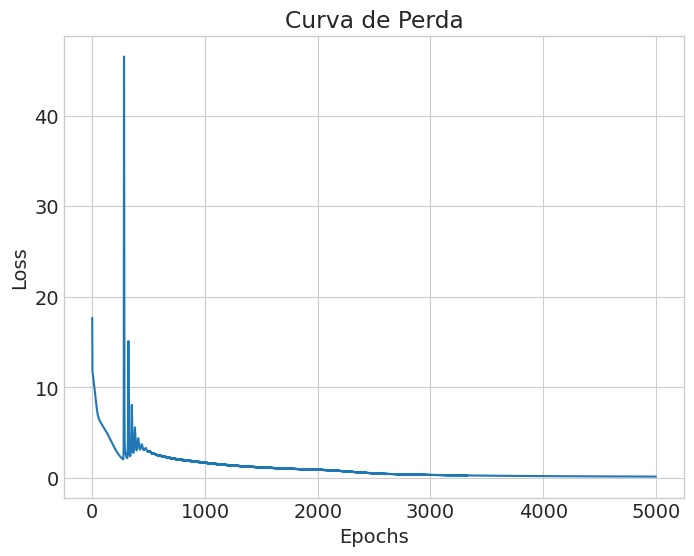

In [63]:
plt.figure(figsize=(8,6))
plt.plot(loss_history_regression)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Curva de Perda")
plt.show()

In [57]:
def plot_regression_curve(model, X, y):
    # Se X for 2D (n_samples, 1), achata para 1D p/ plot
    X = X.reshape(-1, 1)
    y = y.reshape(-1, 1)

    sort_idx = np.argsort(X[:, 0])
    X_sorted = X[sort_idx]

    # Predição do modelo
    y_pred = model.forward(X_sorted)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, label="Dados reais", alpha=0.6)
    plt.plot(X_sorted, y_pred, color="red", linewidth=2, label="Modelo")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.title("Curva do modelo")
    plt.show()

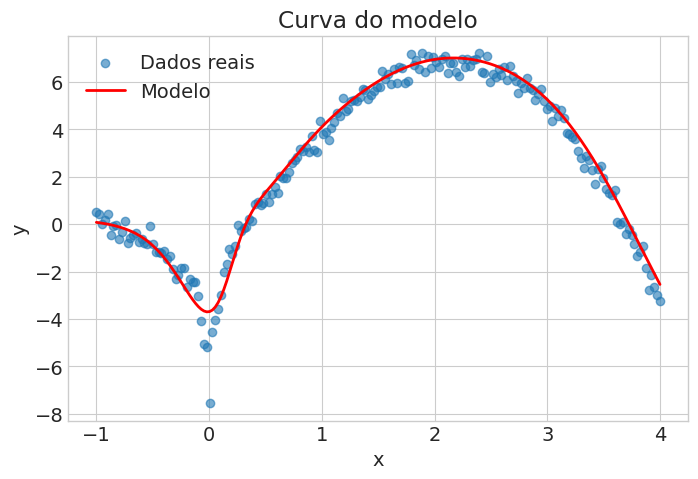

In [65]:
plot_regression_curve(model_regression, X_data, y_data)

## Exercício 7: Compare sua implementação com PyTorch ou JAX

Agora que você construiu e treinou um framework do zero, é hora de apreciar o poder e a conveniência das bibliotecas modernas de Deep Learning.

**A Tarefa:**

Escolha um dos problemas de classificação tratados hoje (e.g., "Duas Luas" ou "Círculos Concêntricos") e desenvolva uma nova implementação para resolvê-lo usando **PyTorch** ou **JAX**.

**O que comparar:**

* **Complexidade do Código:** Compare a quantidade de código necessária para definir o modelo, o custo e o loop de treinamento na sua implementação NumPy vs. a do framework.
* **Facilidade de Uso:** Quão mais fácil foi gerenciar os gradientes, os parâmetros e a atualização dos pesos?
* **Performance:** Houve diferença na velocidade de treinamento ou na acurácia final do modelo?

O objetivo é refletir sobre as abstrações que os frameworks modernos fornecem e entender o que está acontecendo "por baixo dos panos" quando você chama funções como `loss.backward()` e `optimizer.step()`.

In [56]:
sequential_torch = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1),
    nn.Sigmoid()
)

loss_fn_torch = nn.BCELoss()
optimizer_torch = optim.SGD(sequential_torch.parameters(), lr= 0.15)

epochs = 5000
loss_history_torch = []

X_torch = torch.tensor(X_circles, dtype=torch.float32)
y_torch = torch.tensor(y_circles, dtype=torch.float32)

for epoch in range(epochs):
    y_pred = sequential_torch(X_torch)

    loss = loss_fn_torch(y_pred, y_torch)
    loss_history_torch.append(loss.item())

    optimizer_torch.zero_grad()
    loss.backward()
    optimizer_torch.step()
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 500/5000, Loss: 0.1937
Epoch 1000/5000, Loss: 0.0455
Epoch 1500/5000, Loss: 0.0219
Epoch 2000/5000, Loss: 0.0138
Epoch 2500/5000, Loss: 0.0098
Epoch 3000/5000, Loss: 0.0076
Epoch 3500/5000, Loss: 0.0061
Epoch 4000/5000, Loss: 0.0051
Epoch 4500/5000, Loss: 0.0043
Epoch 5000/5000, Loss: 0.0038


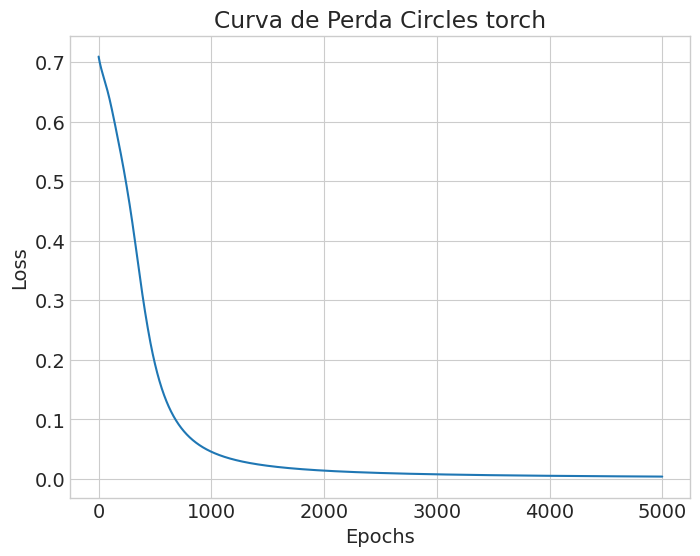

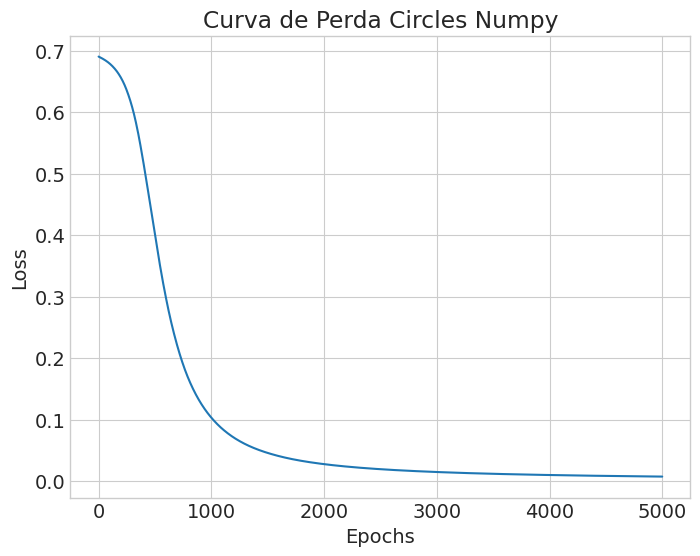

In [60]:
plot_loss(loss_history= loss_history_torch, name = "Circles torch")
plot_loss(loss_history_circles, "Circles Numpy")


#### Resposta

O **treinamento** de ambas tem tamanho e resultado similar. A questão aqui é o tempo de implementação das classes do framework numpy, que não existe no Torch, uma vez que a já estamos usando a implementação pronta.

Em questão de tempo de execução, ambas tiveram bons rendimentos, terminando sua execução em poucos segundos para o dataset dos círculos. 

Em geral a atividade foi interessante, porque, pensando bem, dificilmente nos preocupamos com o que acontece debaixo dos panos quando chamamos uma função/método de uma biblioteca consolidada e prática com o pytorch. E é extremamente proveitoso quando implementamos "na mão" ao menos uma vez, pois conseguimos entender melhor os modelos e suas arquiteturas.

# Questão 2

1. Novas Ativações: Crie as classes ‘Tanh‘ e ‘ReLU‘, implementando seus respectivos métodos ‘forward‘ e ‘backward‘.


In [107]:
class Tanh(Differentiable):
    def __init__(self):
        self.output = None
        
    def forward(self, input_data):
        self.output = np.tanh(input_data)
        return self.output

    def backward(self, output_grad):
        # tanh'(z) = 1 - tanh(z)^2
        return output_grad * (1 - self.output ** 2)


2. Softmax e Cross-Entropy: Crie uma classe ‘MultiClassCrossEntropyLoss‘ e classe ‘Softmax‘ . O método ‘forward‘ deve receber probabilidades normalizadas das classes e calcular o custo (cross-entropy). O método ‘backward‘ deve retornar o gradiente para cada classe, aproveitando a simplificação matemática que vimos em aula.


In [104]:
class MultiClassEntropyLoss(Differentiable):
    def forward(self, y_pred, y_true):
        self.y_pred = np.clip(y_pred, 1e-12, 1) # vetor de prob normalizadas
        self.y_true = y_true # vetor one-hot
        loss = -np.sum(y_true * np.log(self.y_pred)) / y_true.shape[0]
        return loss

    def backward(self):
        # usando a simplificacao matematica
        return (self.y_pred - self.y_true) / y_true.shape[0]


class Softmax(Differentiable):
    def __init__(self):
        self.output = None

    def forward(self, input_data):
        exp_shifted = np.exp(input_data - np.max(input_data, axis=1, keepdims=True))
        self.output = exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)
        return self.output
    
    def backward(self, output_grad):
        # usando a simplificação da softmax + MCEL
        return output_grad


3. Classificação Multiclasse: Utilize as classes ‘MultiClassCrossEntropyLoss‘ e ‘Softmax‘ para implementar um classificar multiclasse e teste no conjunto de dados MNIST. Teste inicialmente com duas classes, depois com três ou quatro (escolha alguns números aleatórios). Dica: o notebook do laboratório tem código para carregar os dados do MNIST. Mostre o erro de treinamento e teste, e as curva da loss durante o treinamento.

Carregar os dados e implementar o modelo

In [103]:
# Carregar o dataset MNIST
train_data = MNIST(root='./data', train=True, download=True, transform=ToTensor())

data = train_data.data.float() / 255.0  # Normalizar para [0, 1]
labels = train_data.targets

# Flatten das imagens (28x28 -> 784) e converter p/ NumPy
data_flat = data.reshape(-1, 28 * 28).numpy()
labels = labels.numpy().astype(np.float32).reshape(-1, 1)

num_classes = 10
y_onehot = np.zeros((labels.size, num_classes))
y_onehot[np.arange(labels.size), labels.astype(int)] = 1

Ao tentar treinar esse modelo como os demais tive muitos problemas.
Principalmente relacionadas a "explosão" do gradiente, por isso tive que alterar a função de `train_model` para que ela pudessse ser feita com `mini_batchs`

In [105]:
def train_model(model, loss_fn, optimizer, X, y, epochs=5000, interval=500, batch_size=None):
    loss_history = []
    n_samples = X.shape[0]

    for epoch in range(epochs):
        if batch_size is not None:
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
        else:
            indices = np.arange(n_samples)

        epoch_loss = 0.0
        n_batches = 0

        step = batch_size if batch_size is not None else n_samples
        for start_idx in range(0, n_samples, step):
            end_idx = start_idx + step
            batch_idx = indices[start_idx:end_idx]

            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            # 1. forward
            y_pred = model.forward(X_batch)

            # 2. loss
            loss = loss_fn.forward(y_pred, y_batch)
            epoch_loss += loss
            n_batches += 1

            # 3. zero grad
            optimizer.zero_grad()

            # 4. backward
            grad_initial = loss_fn.backward()
            model.backward(grad_initial)

            # 5. step
            optimizer.step()

        avg_loss = epoch_loss / n_batches
        loss_history.append(avg_loss)

        if (epoch + 1) % interval == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    return model, loss_history


In [108]:
model_softmax = Sequential([
    Linear(784, 128),
    Tanh(),
    Linear(128, 10),
    Softmax()
])

loss_fn = MultiClassEntropyLoss()
optimizer_softmax = SGD(model_softmax, learning_rate= 0.01)

model_softmax, loss_history_softmax = train_model(
    model_softmax, loss_fn, optimizer_softmax,
    data_flat, y_onehot, epochs=200, interval=10, batch_size=128
)

Epoch [10/200], Loss: 23.0259
Epoch [20/200], Loss: 23.0259
Epoch [30/200], Loss: 23.0259
Epoch [40/200], Loss: 23.0259
Epoch [50/200], Loss: 23.0259
Epoch [60/200], Loss: 23.0259
Epoch [70/200], Loss: 23.0259
Epoch [80/200], Loss: 23.0259
Epoch [90/200], Loss: 23.0259
Epoch [100/200], Loss: 23.0259
Epoch [110/200], Loss: 23.0259
Epoch [120/200], Loss: 23.0259
Epoch [130/200], Loss: 23.0259
Epoch [140/200], Loss: 23.0259
Epoch [150/200], Loss: 23.0259
Epoch [160/200], Loss: 23.0259
Epoch [170/200], Loss: 23.0259
Epoch [180/200], Loss: 23.0259
Epoch [190/200], Loss: 23.0259
Epoch [200/200], Loss: 23.0259


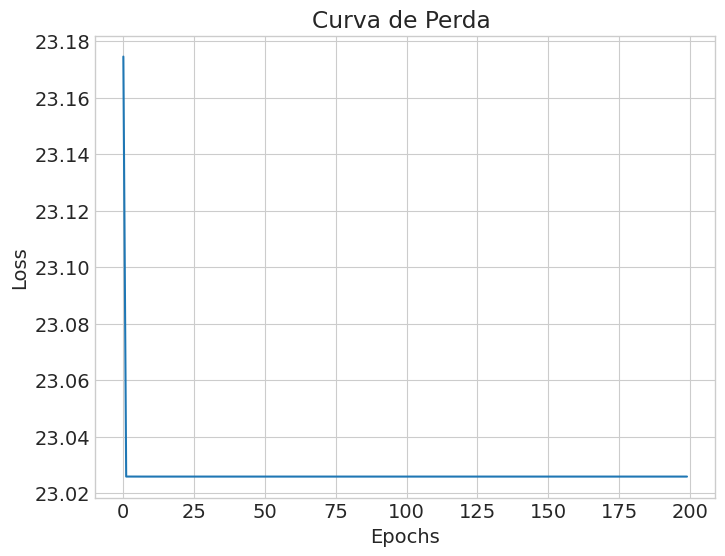

In [109]:
plot_loss(loss_history_softmax)

# Questão 3

O objetivo da regressão simbólica é descobrir a expressão matemática subjacente aos dados. Neste exercício, você usará PyTorch e descida de gradiente para encontrar uma fórmula.
1. Dados: Gere dados a partir de uma função conhecida, e.g., $y = 1.5x^2 −0.8 sin(x)$ + ruído.
2. Biblioteca de Funções: Crie uma biblioteca de funções candidatas:
$\phi(x) = [1,x,x^2,sin(x),cos(x),e^x,..$

Função gerada: y = 1.91 * abs(x) + 2.40 * log_abs(x)


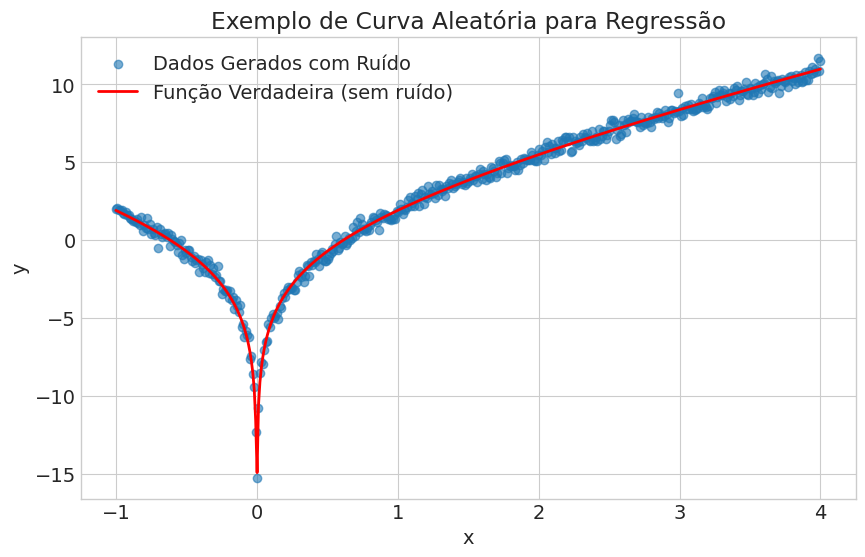

In [86]:
#mesmo codigo do exercicio 7 da questao 1

data_generator = RandomRegressionData()
# Gerar dados
X_data_q3, y_data_q3, func_str, func_terms = data_generator.generate_random_regression_data(n_samples=500, noise=0.3)

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_data_q3, y_data_q3, alpha=0.6, label='Dados Gerados com Ruído')

y_true_q3 = data_generator.evaluate_function(X_data_q3, func_terms)
y_true_q3 = y_true_q3.reshape(-1,1)
plt.plot(X_data_q3, y_true_q3, 'r-', lw=2, label='Função Verdadeira (sem ruído)')

plt.title("Exemplo de Curva Aleatória para Regressão")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
print("Função gerada:", func_str)
plt.show()


In [84]:
def phi(x):
    return torch.cat([
        torch.ones_like(x),
        x,                         
        x**2,                      
        torch.sin(x),              
        torch.cos(x),              
        torch.exp(x)              
    ], dim=1)  

3. Modelo (PyTorch): Crie um modelo que seja uma combinação linear de todas as funções da sua biblioteca: $\hat{y} = w^T \phi(x)$. Os pesos w serão os parâmetros aprendíveis (‘nn.Parameter‘).

In [ ]:
class SymbolicReg(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.w = nn.Parameter(torch.randn(n_features, 1) * 0.1)

    def forward(self, x):
        phi_x = phi(x) 
        y_hat = phi_x @ self.w
        return y_hat


4. Treinamento: Use o otimizador Adam para treinar os pesos w minimizando uma função de custo que combina o Erro Quadrático Médio com uma penalidade L1 sobre os pesos: $J = MSE + \lambda||w||_1$. A regularização L1 é crucial para induzir esparsidade (levar pesos irrelevantes a zero)

In [97]:
model_q3 = SymbolicReg(n_features=6)

lambda_l1 = 0.01
optimizer_q3 = optim.Adam(model_q3.parameters(), lr = 0.01)
loss_fn_q3 = nn.MSELoss()
epochs = 5000

loss_history_q3 = []

X_q3 = torch.tensor(X_data_q3, dtype=torch.float32)
y_q3 = torch.tensor(y_true_q3, dtype=torch.float32)

for epoch in range(epochs):

    optimizer_q3.zero_grad()
    
    y_pred = model_q3(X_q3)
    mse = loss_fn_q3(y_pred, y_q3)

    l1 = torch.sum(torch.abs(model_q3.w))
    loss = mse + lambda_l1 * l1

    loss_history_q3.append(loss.item())

    loss.backward()
    optimizer_q3.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 500/5000, Loss: 2.8654
Epoch 1000/5000, Loss: 2.6643
Epoch 1500/5000, Loss: 2.4811
Epoch 2000/5000, Loss: 2.3060
Epoch 2500/5000, Loss: 2.1611
Epoch 3000/5000, Loss: 2.0554
Epoch 3500/5000, Loss: 1.9859
Epoch 4000/5000, Loss: 1.9406
Epoch 4500/5000, Loss: 1.9059
Epoch 5000/5000, Loss: 1.8725


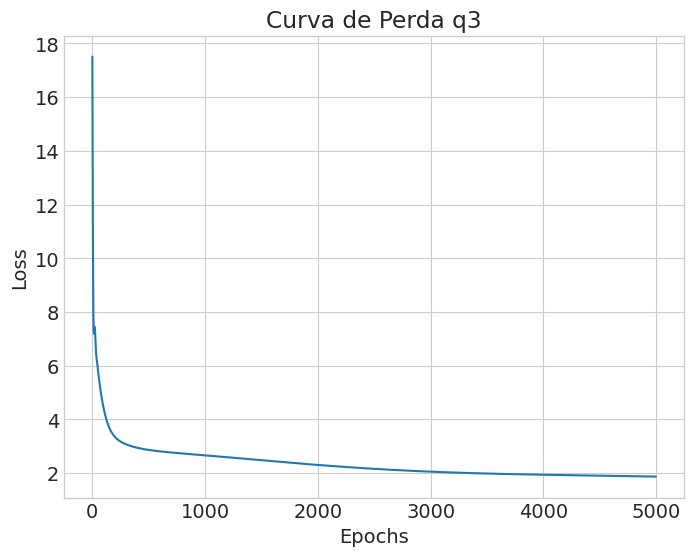

In [99]:
plot_loss(loss_history_q3, "q3")

5. Análise: Inspecione os pesos w aprendidos. Quais pesos têm magnitude significativa? A combinação dos termos com pesos não-nulos se assemelha à função original? Apresente os pesos e a fórmula descoberta

In [100]:
with torch.no_grad():
    w = model_q3.w.squeeze().numpy()
    print("Pesos aprendidos:", w)

terms = ["1", "x", "x^2", "sin(x)", "cos(x)", "exp(x)"]
for t, w_i in zip(terms, w):
    print(f"{w_i:+.3f} * {t}")


Pesos aprendidos: [ 1.4483818 -7.654851   2.5252771  8.109665  -4.564831   0.0679725]
+1.448 * 1
-7.655 * x
+2.525 * x^2
+8.110 * sin(x)
-4.565 * cos(x)
+0.068 * exp(x)


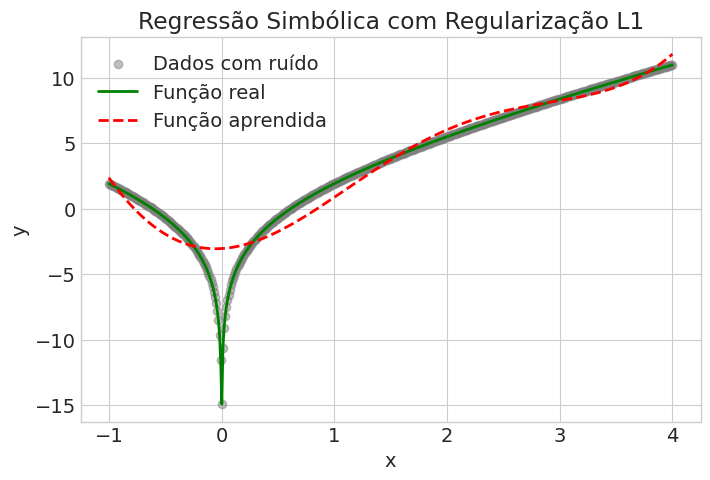

In [101]:
with torch.no_grad():
    y_pred = model_q3(X_q3)

plt.figure(figsize=(8,5))
plt.scatter(X_q3, y_q3, label='Dados com ruído', color='gray', alpha=0.5)
plt.plot(X_q3, y_true_q3, label='Função real', color='green', linewidth=2)
plt.plot(X_q3, y_pred, label='Função aprendida', color='red', linestyle='--', linewidth=2)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressão Simbólica com Regularização L1')
plt.show()

$$\hat{f}(x)+1.448 -7.655 * x +2.525 * x^2 +8.110 * sin(x) -4.565 * cos(x) +0.068 * exp(x)$$

$$f(x) = 1.91 * x + 2.40 * log(x) $$

- Percebe-se que o modelo foi incapaz de se perceber o comportamento da função quando ela está próxima de zero. 
- Provavelmente isso se deve ao comportamento da função log, que não está no dicionário de funções criadas.
- O gráfico do modelo não possui esse movimento de descida e subida brusca, apesar de tentar simular esse comportamento de maneira muito mais suavizada.